In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

In [ ]:
!pip install openexr Imath numpy matplotlib
# !pip install opencv-python-headless
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import cv2
import matplotlib.pyplot as plt
import OpenEXR
import Imath

def read_exr(path):
    exr = OpenEXR.InputFile(path)
    header = exr.header()

    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

    r = np.frombuffer(exr.channel('R', FLOAT), dtype=np.float32)
    g = np.frombuffer(exr.channel('G', FLOAT), dtype=np.float32)
    b = np.frombuffer(exr.channel('B', FLOAT), dtype=np.float32)

    r = r.reshape(height, width)
    g = g.reshape(height, width)
    b = b.reshape(height, width)

    img = np.stack([r, g, b], axis=0)  # CHW

    img = np.log1p(img)
    img = img / (img.max() + 1e-8)

    return img

In [ ]:
img = cv2.imread("/content/drive/MyDrive/469_data/room3/25136394-08192spp.exr", cv2.IMREAD_UNCHANGED)
print(img is None)

False


In [ ]:
class MonteCarloDataset(Dataset):
    def __init__(self, root_dirs, patch_size=128, full_image=False):
        self.pairs = []
        self.patch_size = patch_size
        self.full_image = full_image

        for root in root_dirs:
            files = os.listdir(root)

            for f in files:
                if "00128spp.exr" in f:
                    base = f.split("-00128spp.exr")[0]
                    clean_name = base + "-08192spp.exr"

                    noisy_path = os.path.join(root, f)
                    clean_path = os.path.join(root, clean_name)

                    if os.path.exists(clean_path):
                        self.pairs.append((noisy_path, clean_path))

        print("Total pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx]

        noisy = read_exr(noisy_path)
        clean = read_exr(clean_path)

        if not self.full_image:
          C, H, W = noisy.shape
          ps = self.patch_size

          top = np.random.randint(0, max(1, H - ps))
          left = np.random.randint(0, max(1, W - ps))

          noisy = noisy[:, top:top+ps, left:left+ps]
          clean = clean[:, top:top+ps, left:left+ps]

        noisy = torch.from_numpy(noisy)
        clean = torch.from_numpy(clean)

        return noisy, clean

In [ ]:
train_dataset = MonteCarloDataset([
    "/content/drive/MyDrive/469_data/room2",
    "/content/drive/MyDrive/469_data/room3"
])

Total pairs: 388


In [ ]:
test_dataset = MonteCarloDataset(
    ["/content/drive/MyDrive/469_data/car2"],
    full_image=True
)

Total pairs: 180


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

In [ ]:
from kpcn_model import KPCN

device = "cuda" if torch.cuda.is_available() else "cpu"

model = KPCN().to(device)

In [ ]:
import torch.nn.functional as F

def compute_psnr(output, target):
    mse = F.mse_loss(output, target)
    psnr = -10 * torch.log10(mse + 1e-8)
    return psnr.item()

def loss_func(output, target):
    l1 = F.l1_loss(output, target)
    mse = F.mse_loss(output, target)
    return 0.8 * l1 + 0.2 * mse

In [ ]:
from skimage.metrics import structural_similarity as ssim

def compute_ssim(output, target):

    out_np = output[0].squeeze().permute(1,2,0).cpu().numpy()
    target_np = target[0].squeeze().permute(1,2,0).cpu().numpy()

    score = ssim(out_np, target_np, channel_axis=2, data_range=1.0)

    return score


def compute_variance(tensor):
    return torch.var(tensor, dim=[2,3]).mean().item()

In [ ]:
# =========================
# TRAIN 30 EPOCHS
# =========================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
# criterion = torch.nn.L1Loss()

epochs = 30

train_losses = []
train_psnr = []
best_psnr = float('-inf')

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_psnr = 0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        output = model(noisy)

        # loss = criterion(output, clean)
        loss = loss_func(output, clean)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_psnr += compute_psnr(output, clean)

    avg_loss = total_loss / len(train_loader)
    avg_psnr = total_psnr / len(train_loader)

    train_losses.append(avg_loss)
    train_psnr.append(avg_psnr)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} PSNR: {avg_psnr:.2f} dB")

    #Save best performing model
    if avg_psnr > best_psnr:
        best_psnr = avg_psnr
        torch.save(model.state_dict(), "/content/drive/MyDrive/469_baseline_model_checkpoints/kpcn_best.pt")
        print(f"Best model saved at epoch {epoch+1} with PSNR: {best_psnr:.2f} dB")

    if (epoch + 1) % 3 == 0:
        checkpoint_path = f"/content/drive/MyDrive/469_baseline_model_checkpoints/kpcn_checkpoint_epoch_{epoch+1}.pt"

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        }, checkpoint_path)

        print(f"Checkpoint saved at epoch {epoch+1}")
    scheduler.step()

Epoch [1/30] Loss: 0.0267 PSNR: 25.62 dB
Best model saved at epoch 1 with PSNR: 25.62 dB
Epoch [2/30] Loss: 0.0226 PSNR: 27.07 dB
Best model saved at epoch 2 with PSNR: 27.07 dB
Epoch [3/30] Loss: 0.0195 PSNR: 28.66 dB
Best model saved at epoch 3 with PSNR: 28.66 dB
Checkpoint saved at epoch 3
Epoch [4/30] Loss: 0.0201 PSNR: 28.60 dB
Epoch [5/30] Loss: 0.0188 PSNR: 29.43 dB
Best model saved at epoch 5 with PSNR: 29.43 dB
Epoch [6/30] Loss: 0.0172 PSNR: 29.83 dB
Best model saved at epoch 6 with PSNR: 29.83 dB
Checkpoint saved at epoch 6
Epoch [7/30] Loss: 0.0160 PSNR: 30.70 dB
Best model saved at epoch 7 with PSNR: 30.70 dB
Epoch [8/30] Loss: 0.0190 PSNR: 29.21 dB
Epoch [9/30] Loss: 0.0166 PSNR: 30.80 dB
Best model saved at epoch 9 with PSNR: 30.80 dB
Checkpoint saved at epoch 9
Epoch [10/30] Loss: 0.0177 PSNR: 30.02 dB
Epoch [11/30] Loss: 0.0164 PSNR: 30.67 dB
Epoch [12/30] Loss: 0.0170 PSNR: 30.43 dB
Checkpoint saved at epoch 12
Epoch [13/30] Loss: 0.0160 PSNR: 30.45 dB
Epoch [14/30] 

In [ ]:
# Save model
torch.save(model.state_dict(), "/content/drive/MyDrive/469_baseline_model_checkpoints/kpcn_model.pt")
print("Final model saved!")

Final model saved!


In [ ]:
# checkpoint = torch.load("/content/drive/MyDrive/kpcn_checkpoint_epoch_6.pt")

# model = KPCN().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# start_epoch = checkpoint['epoch']

# print(f"Resuming from epoch {start_epoch}")

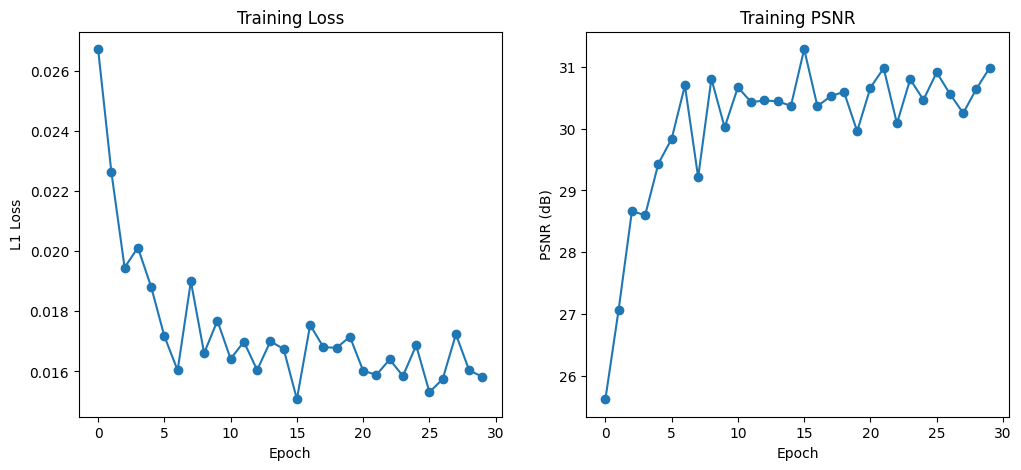

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")

# PSNR curve
plt.subplot(1,2,2)
plt.plot(train_psnr, marker='o')
plt.title("Training PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")

plt.show()

In [ ]:
# =============================
# EVALUATE TEST PERFORMANCE
# =============================

model.load_state_dict(torch.load("/content/drive/MyDrive/469_baseline_model_checkpoints/kpcn_best.pt"))
if model is None:
    print("Model not found!")
print("Model loaded!")

model.eval()

total_psnr = 0
total_ssim = 0
total_noisy_var = 0
total_denoised_var = 0
total_nosiy_psnr = 0
count = 0

with torch.no_grad():
    torch.cuda.empty_cache()
    for noisy, clean in test_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        output = model(noisy)

        psnr = compute_psnr(output, clean)
        noiy_psnr = compute_psnr(noisy, clean)
        ssim_score = compute_ssim(output, clean)

        noisy_var = compute_variance(noisy)
        denoised_var = compute_variance(output)

        total_psnr += psnr
        total_nosiy_psnr += noiy_psnr
        total_ssim += ssim_score
        total_noisy_var += noisy_var
        total_denoised_var += denoised_var

        count += 1

avg_psnr = total_psnr / count
avg_ssim = total_ssim / count
avg_noisy_var = total_noisy_var / count
avg_noisy_psnr = total_nosiy_psnr / count
avg_denoised_var = total_denoised_var / count

print("Average Test PSNR (Low Spp Noisy Image):", avg_noisy_psnr, "dB")
print("Average Test PSNR (Model Output):", avg_psnr, "dB")
print(f"PSNR Improvement: {avg_psnr - avg_noisy_psnr:.2f} dB")
print("Average Test SSIM:", avg_ssim)
print("Average Noisy Variance:", avg_noisy_var)
print("Average Denoised Variance:", avg_denoised_var)
print("Variance Reduction:", avg_noisy_var - avg_denoised_var)

Model loaded!
Average Test PSNR (Low Spp Noisy Image): 41.907278230455184 dB
Average Test PSNR (Model Output): 39.28025669521756 dB
PSNR Improvement: -2.63 dB
Average Test SSIM: 0.9595421
Average Noisy Variance: 0.007932180486710018
Average Denoised Variance: 0.008113097199909842
Variance Reduction: -0.00018091671319982357


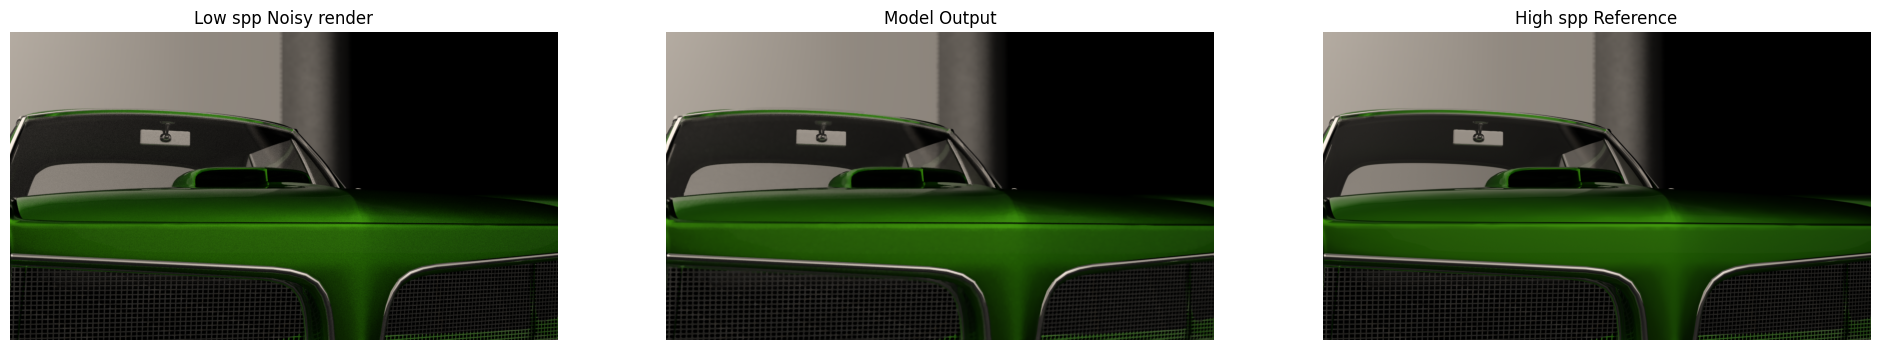

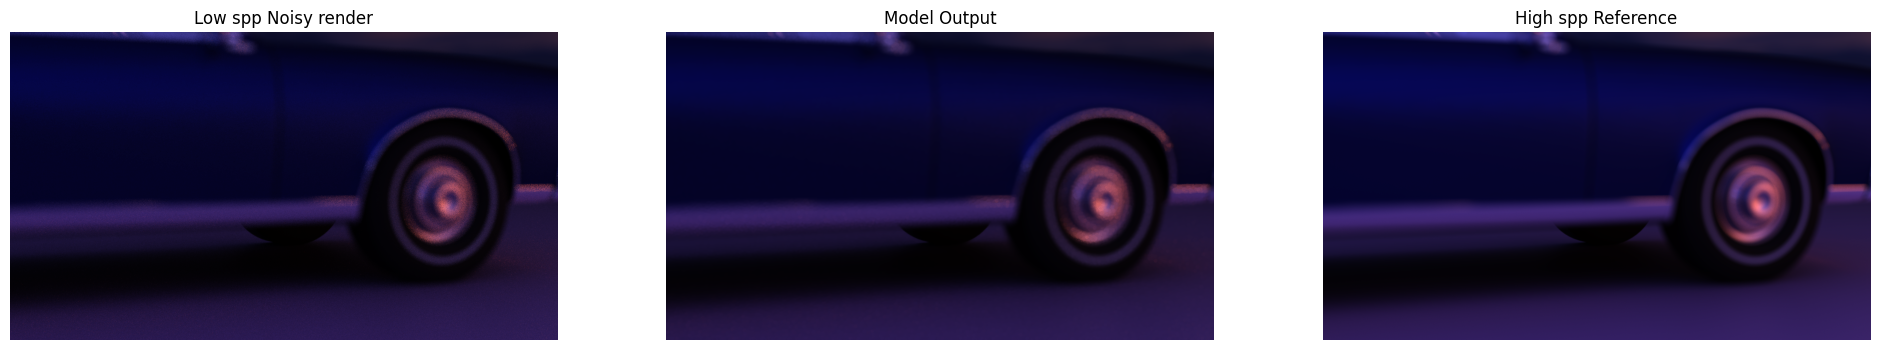

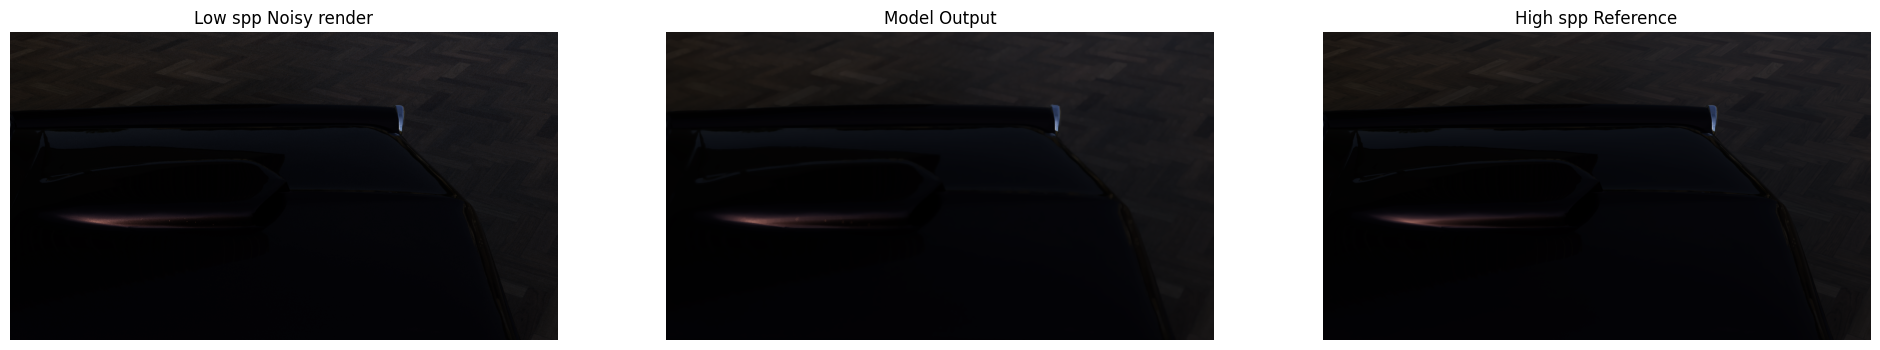

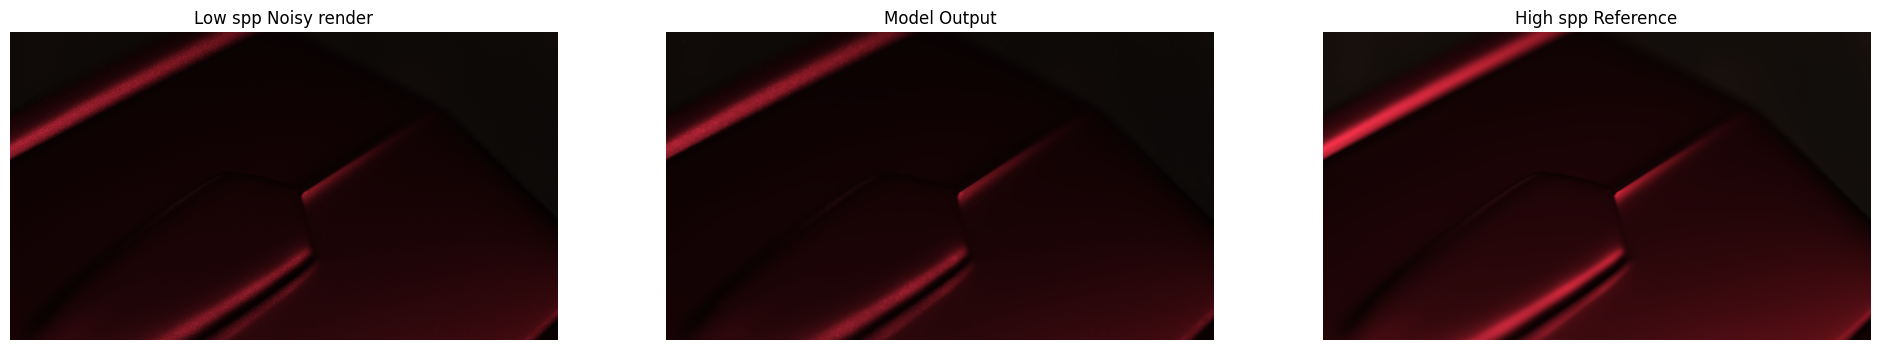

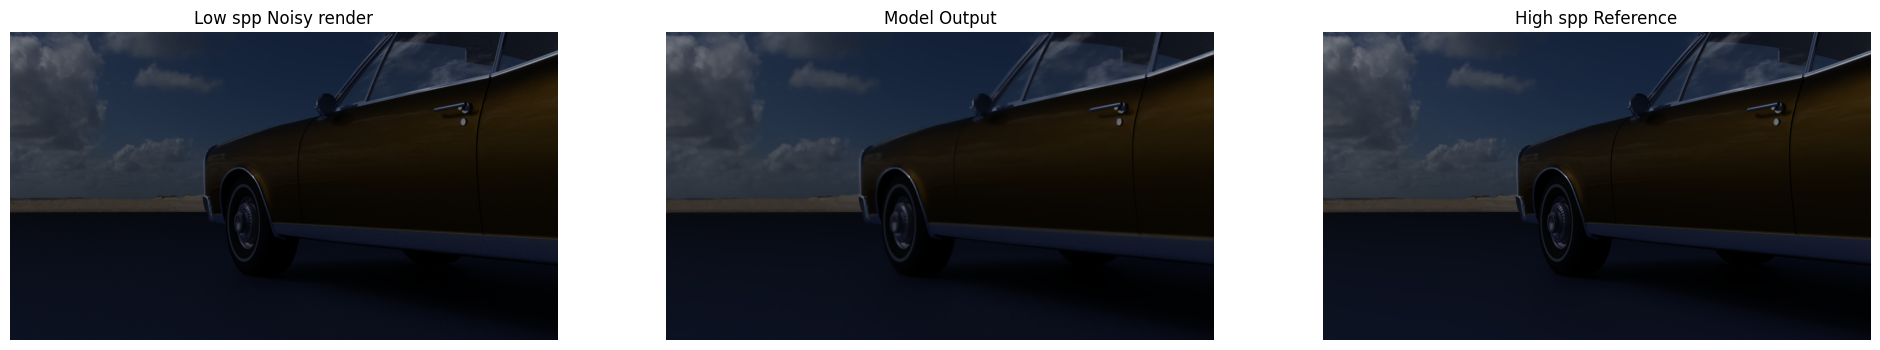

In [ ]:
# =========================
# VISUALIZE RESULTS
# =========================

import random

model.eval()
num_samples = 5

indices = random.sample(range(len(test_dataset)), num_samples)
with torch.no_grad():
    # for i, (noisy, clean) in enumerate(test_loader):
    #     if i >= num_samples:
    #         break
        # noisy = noisy.to(device)
        # clean = clean.to(device)
    for i in indices:
        noisy, clean = test_dataset[i]

        noisy = noisy.unsqueeze(0).to(device)
        clean = clean.unsqueeze(0).to(device)

        output = model(noisy)

        # Convert tensors to numpy
        noisy_np = noisy.squeeze(0).permute(1,2,0).cpu().numpy()
        clean_np = clean.squeeze(0).permute(1,2,0).cpu().numpy()
        out_np = output.squeeze(0).permute(1,2,0).cpu().numpy()

        # Clip for display
        noisy_np = np.clip(noisy_np, 0, 1)
        clean_np = np.clip(clean_np, 0, 1)
        out_np = np.clip(out_np, 0, 1)

        import matplotlib.pyplot as plt

        plt.figure(figsize=(24,8))

        plt.subplot(1,3,1)
        plt.title("Low spp Noisy render")
        plt.imshow(noisy_np)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Model Output")
        plt.imshow(out_np)
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("High spp Reference")
        plt.imshow(clean_np)
        plt.axis("off")

        plt.show()

In [ ]:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# for i in range(100):
#     optimizer.zero_grad()
#     output = model(noisy)
#     loss = torch.nn.functional.l1_loss(output, clean)
#     loss.backward()
#     optimizer.step()

#     if i % 20 == 0:
#         print(i, loss.item())